In [31]:
import sys
sys.path.append("../")

# Force reload of modules to pick up the fix
if 'Classes.Persistence' in sys.modules:
    del sys.modules['Classes.Persistence']
if 'Classes.Solution' in sys.modules:
    del sys.modules['Classes.Solution']
if 'Classes.Problem' in sys.modules:
    del sys.modules['Classes.Problem']
if 'Classes.Convergence' in sys.modules:
    del sys.modules['Classes.Convergence']
if 'Classes.Log' in sys.modules:
    del sys.modules['Classes.Log']

from Classes.Solution import Solution
from Classes.Persistence import PersistMultipleSolutions, PersistSingleSolution
from Classes.utils import boxplot_fx, boxplot_convergence, get_fx_samples
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np

ils = PersistMultipleSolutions().load(filename="ils_1600", filepath="./ils/results/")
vns = PersistMultipleSolutions().load(filename="vns_1600", filepath="./vns/results/")
ga = PersistMultipleSolutions().load(filename="ga_1600", filepath="./ga/results/")
optimum = PersistSingleSolution().load(filename="globopt_1600", filepath="./global_optimum/results/")

ils = ils[2]
vns = vns[0]
ga = ga[2]
solutions = [ils, vns, ga]
names = ["ILS", "VNS", "GA"]

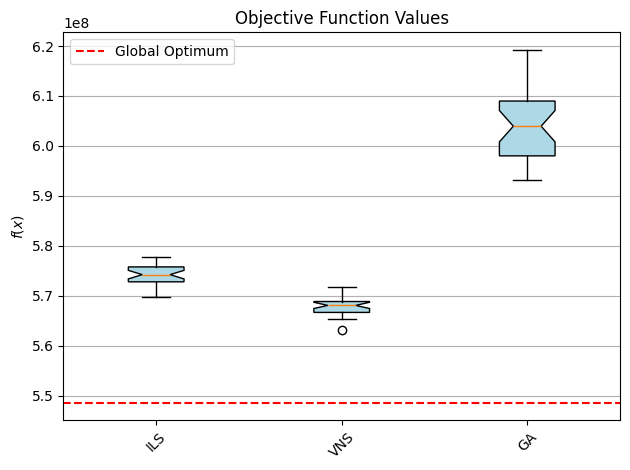

In [32]:
boxplot_fx(solutions, names, global_optimum=optimum)

In [33]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
fx = get_fx_samples(solutions)
alpha = 0.05

# Compare VNS vs ILS
print("=" * 50)
print("COMPARISON: VNS (Algorithm 2) vs ILS (Algorithm 1)")
print("=" * 50)
fx_comparison = [fx[1], fx[0]]  # VNS vs ILS

# Test for normality
print("\nShapiro-Wilk Test p-values:")
p_values = []
for i, name in enumerate(["VNS", "ILS"]):
    stat, p = shapiro(fx_comparison[i])
    p_values.append(p)
    print(f"{name}: {p:.4f}")

both_normal = all(p > alpha for p in p_values)
print(f"\nBoth samples normally distributed: {both_normal}")

# Choose appropriate test
if both_normal:
    print("\nUsing parametric t-test:")
    stat, p = ttest_ind(fx_comparison[0], fx_comparison[1], equal_var=False, alternative='less')
    print(f"T-test p-value: {p:.4f}")
else:
    print("\nUsing non-parametric Mann-Whitney U test:")
    stat, p = mannwhitneyu(fx_comparison[0], fx_comparison[1], alternative='less')
    print(f"Mann-Whitney U test p-value: {p:.4f}")

if p < alpha:
    print("✓ Result: VNS is significantly better than ILS (p < 0.05)")
else:
    print("✗ Result: No significant difference between VNS and ILS (p >= 0.05)")

# Compare VNS vs GA
print("\n" + "=" * 50)
print("COMPARISON: VNS (Algorithm 2) vs GA (Algorithm 3)")
print("=" * 50)
fx_comparison = [fx[1], fx[2]]  # VNS vs GA

# Test for normality
print("\nShapiro-Wilk Test p-values:")
p_values = []
for i, name in enumerate(["VNS", "GA"]):
    stat, p = shapiro(fx_comparison[i])
    p_values.append(p)
    print(f"{name}: {p:.4f}")

both_normal = all(p > alpha for p in p_values)
print(f"\nBoth samples normally distributed: {both_normal}")

# Choose appropriate test
if both_normal:
    print("\nUsing parametric t-test:")
    stat, p = ttest_ind(fx_comparison[0], fx_comparison[1], equal_var=False, alternative='less')
    print(f"T-test p-value: {p:.4f}")
else:
    print("\nUsing non-parametric Mann-Whitney U test:")
    stat, p = mannwhitneyu(fx_comparison[0], fx_comparison[1], alternative='less')
    print(f"Mann-Whitney U test p-value: {p:.4f}")

if p < alpha:
    print("✓ Result: VNS is significantly better than GA (p < 0.05)")
else:
    print("✗ Result: No significant difference between VNS and GA (p >= 0.05)")

COMPARISON: VNS (Algorithm 2) vs ILS (Algorithm 1)

Shapiro-Wilk Test p-values:
VNS: 0.3556
ILS: 0.1913

Both samples normally distributed: True

Using parametric t-test:
T-test p-value: 0.0000
✓ Result: VNS is significantly better than ILS (p < 0.05)

COMPARISON: VNS (Algorithm 2) vs GA (Algorithm 3)

Shapiro-Wilk Test p-values:
VNS: 0.3556
GA: 0.1268

Both samples normally distributed: True

Using parametric t-test:
T-test p-value: 0.0000
✓ Result: VNS is significantly better than GA (p < 0.05)


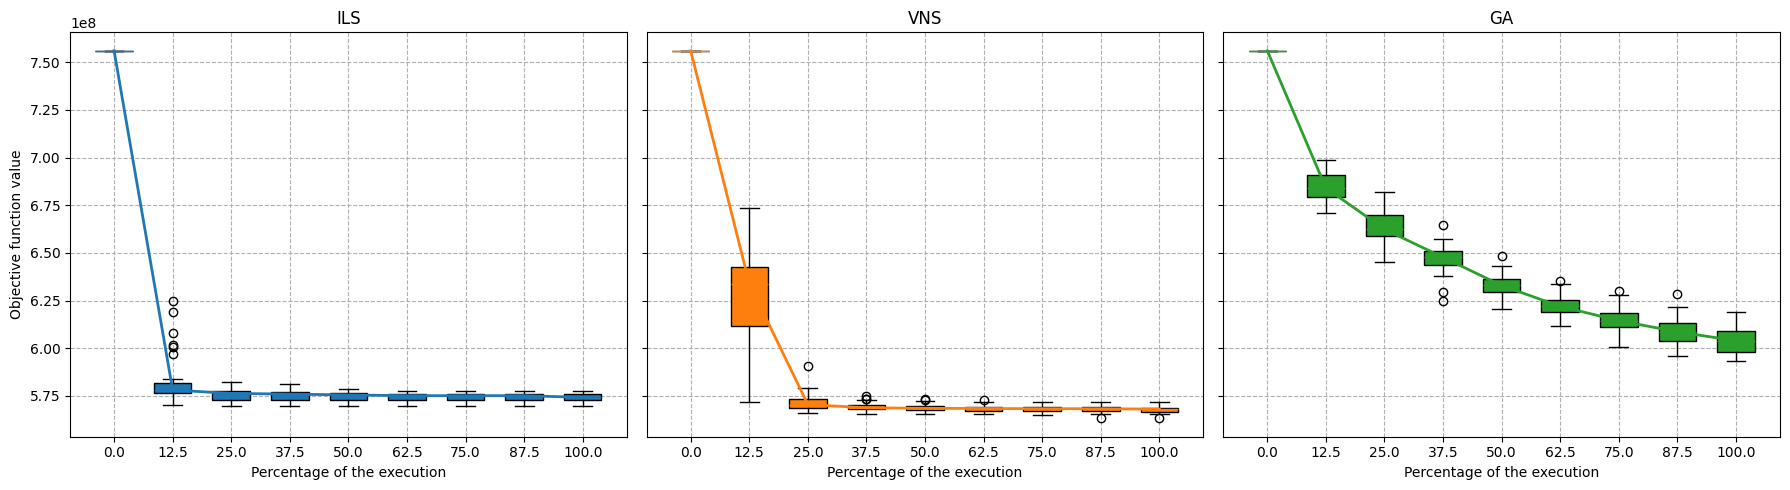

In [34]:
boxplot_convergence(solutions, names)